# A Finite-Dimensional Extremal Theory for Exponential Tilting under Score-Gap Constraints

The results were obtained by executing the script `run_extremal_gibbs_q1pp_v3_final_memorysafe.py` with the following command:

```bash
python run_extremal_gibbs_q1pp_v3_final_memorysafe.py --profile q1pp --seeds 30 --num-random 3000

In [1]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import RegularGridInterpolator

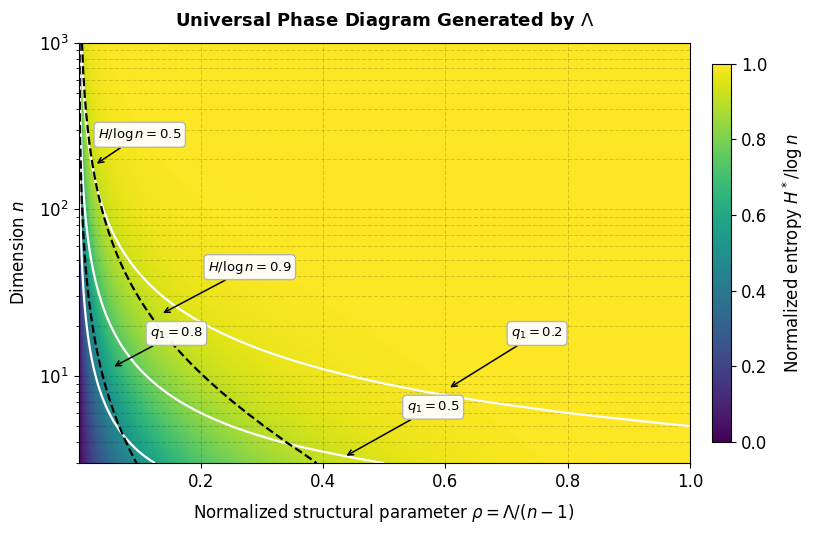

In [2]:
# ==========================================
# Figure 1
# ==========================================
df = pd.read_csv(
    "C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig01_phase_diagram.csv"
)

pivot_H = df.pivot_table(index="n", columns="rho", values="H_over_logn")
pivot_q = df.pivot_table(index="n", columns="rho", values="q1")

rho_raw = pivot_H.columns.to_numpy()
n_raw = pivot_H.index.to_numpy()

log_n_raw = np.log10(n_raw)

rho_fine = np.linspace(rho_raw.min(), rho_raw.max(), 400)
log_n_fine = np.linspace(log_n_raw.min(), log_n_raw.max(), 400)

X_fine, Y_log_fine = np.meshgrid(rho_fine, log_n_fine)
Y_fine = 10**Y_log_fine

interp_H = RegularGridInterpolator((log_n_raw, rho_raw), pivot_H.to_numpy(), bounds_error=False, fill_value=None)
interp_q = RegularGridInterpolator((log_n_raw, rho_raw), pivot_q.to_numpy(), bounds_error=False, fill_value=None)

grid_points = np.array([Y_log_fine.ravel(), X_fine.ravel()]).T
H_fine = interp_H(grid_points).reshape(X_fine.shape)
q_fine = interp_q(grid_points).reshape(X_fine.shape)

plt.rcParams.update({"font.size": 12, "font.family": "sans-serif"})
fig, ax = plt.subplots(figsize=(8.5, 5.5))

im = ax.pcolormesh(
    X_fine, Y_fine, H_fine, shading="gouraud", cmap="viridis", vmin=0, vmax=1
)

c1 = ax.contour(
    X_fine, Y_fine, q_fine, levels=[0.2, 0.5, 0.8], colors="white", linewidths=1.6
)

c2 = ax.contour(
    X_fine,
    Y_fine,
    H_fine,
    levels=[0.5, 0.9],
    colors="black",
    linestyles="dashed",
    linewidths=1.6,
)

arrow_style = dict(arrowstyle="->", color="black", lw=1.1, shrinkA=0, shrinkB=4)
text_style = dict(
    fontsize=9.5,
    color="black",
    weight="semibold",
    va="center",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.annotate(
    r"$H/\log n = 0.5$",
    xy=(0.022, 180),
    xytext=(0.10, 280),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$H/\log n = 0.9$",
    xy=(0.13, 23),
    xytext=(0.28, 45),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_1 = 0.2$",
    xy=(0.60, 8.2),
    xytext=(0.75, 18),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_1 = 0.5$",
    xy=(0.43, 3.2),
    xytext=(0.58, 6.5),
    arrowprops=arrow_style,
    **text_style
)

ax.annotate(
    r"$q_1 = 0.8$",
    xy=(0.05, 11),
    xytext=(0.16, 18),
    arrowprops=arrow_style,
    **text_style
)

ax.set_yscale("log")
ax.set_xlim(rho_fine.min(), rho_fine.max())

ax.set_xlabel(r"Normalized structural parameter $\rho=\Lambda/(n-1)$", labelpad=8)
ax.set_ylabel(r"Dimension $n$", labelpad=8)
ax.set_title(
    r"Universal Phase Diagram Generated by $\Lambda$",
    fontsize=13,
    pad=12,
    weight="bold",
)

ax.grid(True, which="both", linestyle="--", alpha=0.15, color="black")

cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.9)
cbar.set_label(r"Normalized entropy $H^*/\log n$", labelpad=10)

fig.tight_layout()


plt.show()

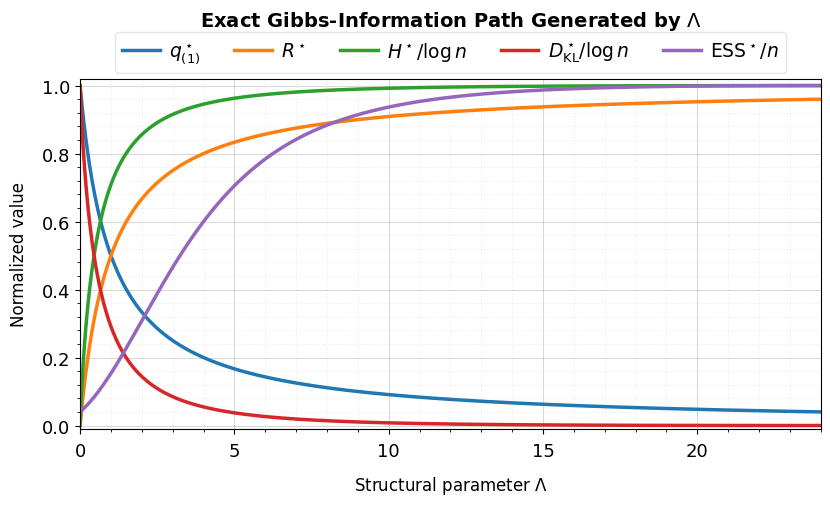

In [3]:
# ==========================================
# Figure 2
# ==========================================

df = pd.read_csv(
    "C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig02_exact_gibbs_information_path.csv"
)

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,
})

colors = {
    "q1": "#1f77b4",   # Bleu
    "R": "#ff7f0e",    # Orange
    "H": "#2ca02c",    # Vert
    "KL": "#d62728",   # Rouge
    "ESS": "#9467bd",  # Violet
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ax.plot(df["lambda"], df["q1"], color=colors["q1"], linewidth=2.5, label=r"$q_{(1)}^\star$")
ax.plot(df["lambda"], df["R"], color=colors["R"], linewidth=2.5, label=r"$R^\star$")
ax.plot(df["lambda"], df["H_over_logn"], color=colors["H"], linewidth=2.5, label=r"$H^\star/\log n$")
ax.plot(df["lambda"], df["KL_over_logn"], color=colors["KL"], linewidth=2.5, label=r"$D_{\mathrm{KL}}^\star/\log n$")
ax.plot(df["lambda"], df["ESS_over_n"], color=colors["ESS"], linewidth=2.5, label=r"$\mathrm{ESS}^\star/n$")

ax.set_xlabel(r"Structural parameter $\Lambda$", labelpad=10, fontsize=12)
ax.set_ylabel("Normalized value", labelpad=10, fontsize=12)

ax.set_title(
    r"Exact Gibbs-Information Path Generated by $\Lambda$",
    fontsize=14,
    pad=38,
    weight="bold",
)

ax.set_xlim(df["lambda"].min(), df["lambda"].max())
ax.set_ylim(-0.01, 1.02)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.08, color="black")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=5,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=13.5,
    columnspacing=1.8,
    handletextpad=0.5,
)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

fig.tight_layout()
plt.show()


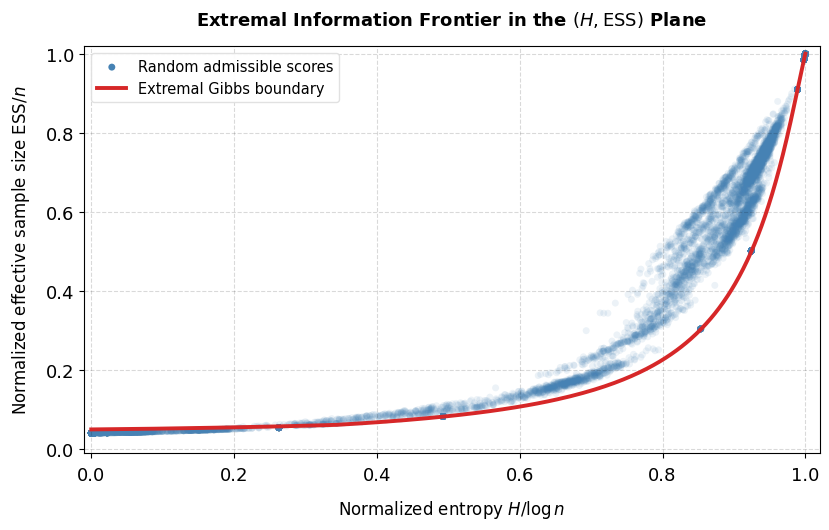

In [4]:
# ==========================================
# Figure 3
# ==========================================


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig03_information_frontier.csv")

random_df = df[df["type"] == "random"].copy()
frontier_df = df[df["type"] == "boundary"].copy()  # Aligné sur le fichier CSV

frontier_df = frontier_df.sort_values("H_over_logn")

window = max(3, len(frontier_df) // 50)
frontier_df["ESS_smooth"] = frontier_df["ESS_over_n"].rolling(window=window, center=True, min_periods=1).mean()
frontier_df["ESS_clean"] = frontier_df["ESS_smooth"].cummax()

valid_mask = (frontier_df["H_over_logn"] > 0.02) | (frontier_df["ESS_clean"] < 0.2)
frontier_plot = frontier_df[valid_mask]

plt.rcParams.update({
    "font.size": 13,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

scatter_points = ax.scatter(
    random_df["H_over_logn"],
    random_df["ESS_over_n"],
    s=25,
    color="#4682b4",
    alpha=0.1,
    edgecolors="none",
    label="Random admissible scores",
)

line_frontier, = ax.plot(
    frontier_plot["H_over_logn"],
    frontier_plot["ESS_clean"],
    color="#d62728",
    linewidth=2.8,
    zorder=3,
    label="Extremal Gibbs boundary",
)

ax.set_xlabel(r"Normalized entropy $H / \log n$", labelpad=10, fontsize=12)
ax.set_ylabel(
    r"Normalized effective sample size $\mathrm{ESS} / n$", labelpad=10, fontsize=12
)
ax.set_title(
    r"Extremal Information Frontier in the $(H, \mathrm{ESS})$ Plane",
    fontsize=13,
    pad=15,
    weight="bold",
)

ax.set_xlim(-0.01, 1.02)
ax.set_ylim(-0.01, 1.02)
ax.grid(True, which="major", linestyle="--", alpha=0.15, color="black")

leg = ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=10.5,
)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

for lh in leg.legend_handles:
    lh.set_alpha(1.0)

fig.tight_layout()
plt.show()


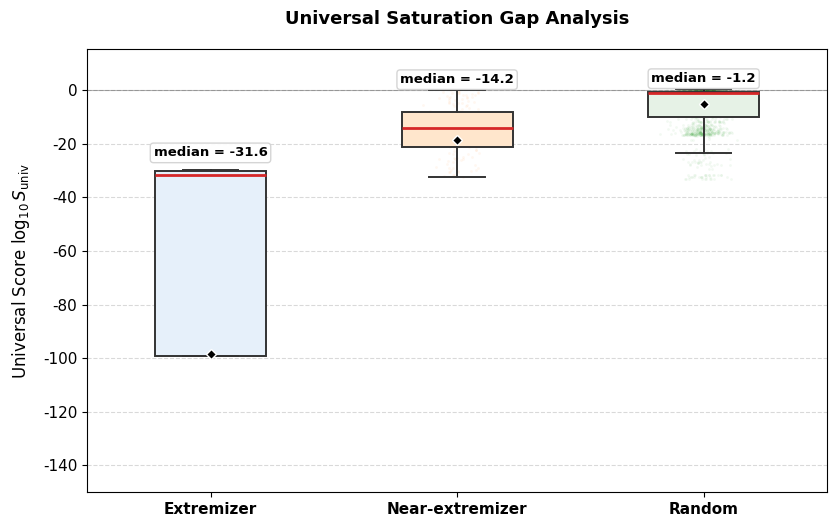

In [5]:
# ==========================================
# Figure 4
# ==========================================

df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig04_saturation_gap.csv")

order = ["extremizer", "near_extremizer", "random"]
labels = ["Extremizer", "Near-extremizer", "Random"]

data = [df.loc[df["case"] == c, "log10_universal_score"].dropna().to_numpy() for c in order]

box_colors = ["#e6f0fa", "#ffe6cc", "#e6f2e6"]
jitter_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.5, 5.4))

bp = ax.boxplot(
    data,
    positions=np.arange(1, 4),
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    medianprops=dict(color="#d62728", linewidth=2.0),  # Ligne médiane rouge académique
    meanprops=dict(
        marker="D",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=5,
    ),
    boxprops=dict(linewidth=1.4, edgecolor="#333333"),
    whiskerprops=dict(linewidth=1.4, color="#333333"),
    capprops=dict(linewidth=1.4, color="#333333"),
    zorder=2,
)

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)

rng = np.random.default_rng(123)

for i, values in enumerate(data):
    if len(values) > 2000:
        values_plot = rng.choice(values, size=2000, replace=False)
    else:
        values_plot = values

    x = rng.normal(loc=i + 1, scale=0.05, size=len(values_plot))

    ax.scatter(
        x,
        values_plot,
        s=4,
        color=jitter_colors[i],
        alpha=0.06,
        linewidths=0,
        zorder=1,
    )

for i, c in enumerate(order):
    values = df.loc[df["case"] == c, "log10_universal_score"].dropna()
    median = values.median()

    q75 = values.quantile(0.75)
    q25 = values.quantile(0.25)
    iqr = q75 - q25
    upper_whisker = values[values <= (q75 + 1.5 * iqr)].max()
    y_pos = upper_whisker + 4.0 if upper_whisker < -5 else upper_whisker + 1.5

    ax.text(
        i + 1,
        y_pos,
        f"median = {median:.1f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        weight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#d3d3d3",
            alpha=0.95,
        ),
    )

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, weight="semibold")

ax.set_ylabel(r"Universal Score $\log_{10} S_{\mathrm{univ}}$", fontsize=12, labelpad=8)
ax.set_title("Universal Saturation Gap Analysis", fontsize=13, weight="bold", pad=18)

ax.grid(axis="y", linestyle="--", alpha=0.15, color="black")
ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.3)

ax.set_ylim(df["log10_universal_score"].min()/2 ,df["log10_universal_score"].max() + 15)

fig.tight_layout()
plt.show()



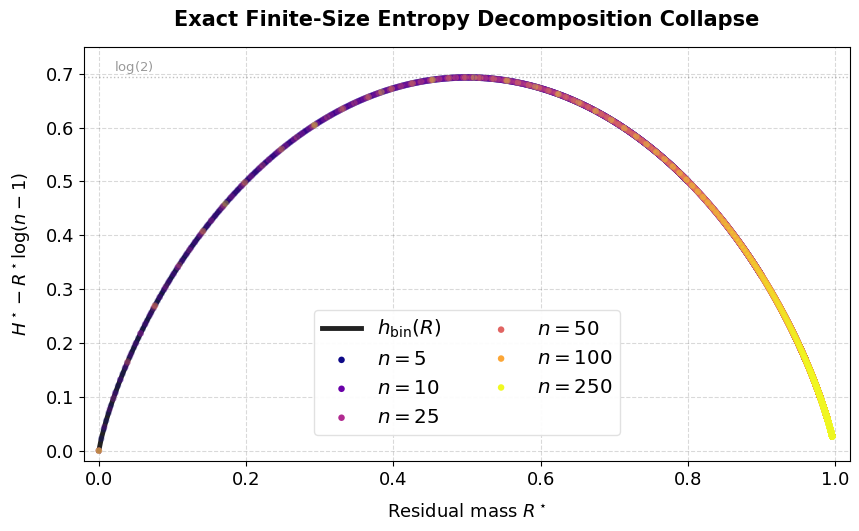

In [6]:
# ==========================================
# Figure 5
# ==========================================


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig05_entropy_decomposition_collapse.csv")

theory = df[["R", "binary_entropy_R"]].drop_duplicates().sort_values("R")

n_values = sorted(df["n"].unique())
num_n = len(n_values)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8.8, 5.5))

cmap = plt.get_cmap("plasma")
ax.plot(
    theory["R"],
    theory["binary_entropy_R"],
    color="#222222",
    linestyle="-",
    linewidth=3.5,
    zorder=2,
    label=r"$h_{\mathrm{bin}}(R)$",
)

for idx, n_value in enumerate(n_values):
    sub = df[df["n"] == n_value].sort_values("R")
    color_fraction = idx / (num_n - 1) if num_n > 1 else 0.5

    ax.scatter(
        sub["R"],
        sub["entropy_binary_part"],
        s=22,
        color=cmap(color_fraction),
        alpha=0.30,
        edgecolors="none",
        zorder=4,
        label=rf"$n={int(n_value)}$"
    )

ax.set_xlabel(r"Residual mass $R^\star$", labelpad=10, fontsize=13)
ax.set_ylabel(r"$H^\star - R^\star \log(n-1)$", labelpad=10, fontsize=13)
ax.set_title("Exact Finite-Size Entropy Decomposition Collapse", fontsize=15, weight="bold", pad=15)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 0.75)

ax.grid(True, linestyle="--", alpha=0.15, color="black")

ax.axhline(0.69315, color="black", linestyle=":", alpha=0.25, linewidth=1.0)
ax.text(0.02, 0.705, r"$\log(2)$", color="black", alpha=0.4, fontsize=9.5)

leg = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=14.3,
    ncol=2,
)

for lh in leg.legend_handles:
    if hasattr(lh, "set_alpha"):
        lh.set_alpha(1.0)

fig.tight_layout()
plt.show()

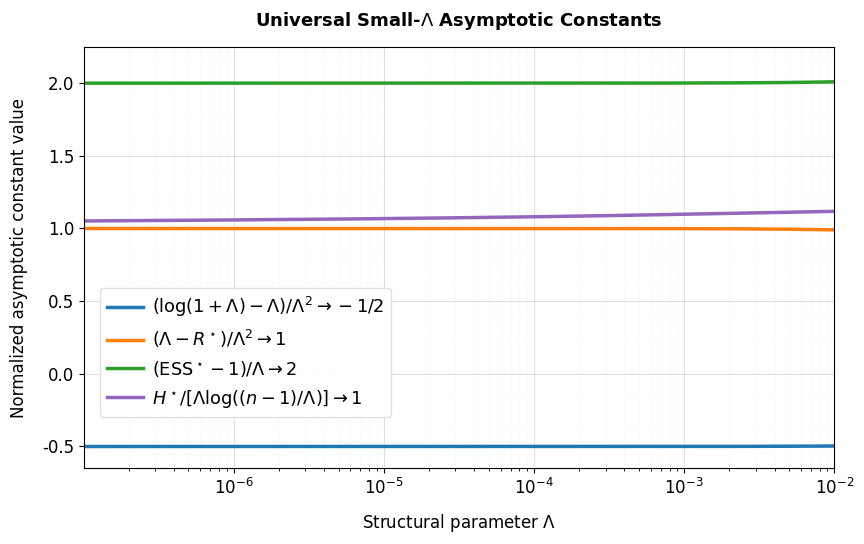

In [7]:
# ==========================================
# Figure 6
# ==========================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.unicode_minus": False,
})

colors = {
    "vbar": "#1f77b4",  # Bleu
    "R": "#ff7f0e",  # Orange
    "ESS": "#2ca02c",  # Vert
    "H": "#9467bd",  # Violet
}


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig06_small_lambda_constants_plot.csv")
df = df.sort_values("lambda")

fig, ax = plt.subplots(figsize=(8.8, 5.6))

ax.plot(df["lambda"], df["c_vbar"], color=colors["vbar"], linewidth=2.5, label=r"$(\log(1+\Lambda)-\Lambda)/\Lambda^2 \to -1/2$")
ax.plot(df["lambda"], df["c_R"], color=colors["R"], linewidth=2.5, label=r"$(\Lambda-R^\star)/\Lambda^2 \to 1$")
ax.plot(df["lambda"], df["c_ESS"], color=colors["ESS"], linewidth=2.5, label=r"$(\mathrm{ESS}^\star-1)/\Lambda \to 2$")
ax.plot(df["lambda"], df["c_H"], color=colors["H"], linewidth=2.5, label=r"$H^\star/[\Lambda\log((n-1)/\Lambda)] \to 1$")

x_min, x_max = df["lambda"].min(), df["lambda"].max()

ax.set_xscale("log")

ax.set_xlabel(r"Structural parameter $\Lambda$", labelpad=10, fontsize=12)
ax.set_ylabel("Normalized asymptotic constant value", labelpad=10, fontsize=12)

ax.set_title(r"Universal Small-$\Lambda$ Asymptotic Constants", fontsize=13, weight="bold", pad=15)

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.65, 2.25)

ax.grid(True, which="major", linestyle="-", alpha=0.12, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.06, color="black")


ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.45),
    ncol=1,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=12.8,
    columnspacing=1.4,
    handletextpad=0.5
)

fig.tight_layout()
plt.show()



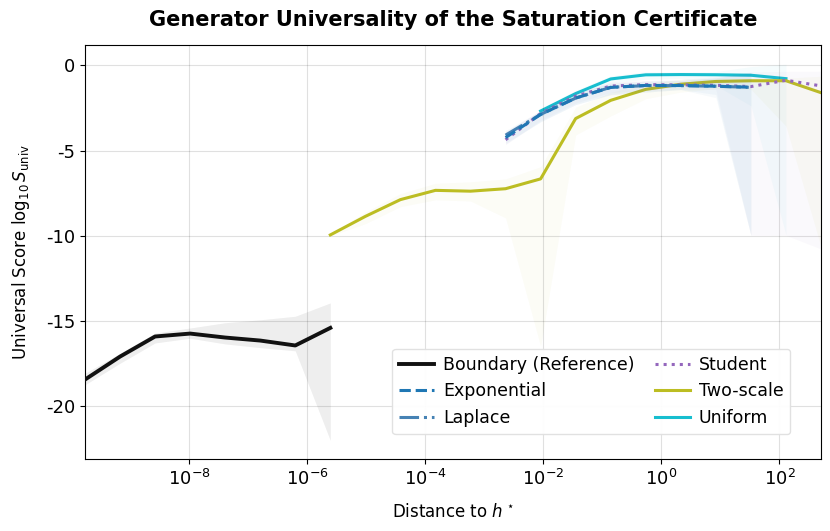

In [8]:
# ==========================================
# Figure 7
# ==========================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.unicode_minus": False,
})


df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig07_generator_universality.csv")

generators = ["boundary", "exponential", "laplace", "student", "two_scale", "uniform"]

fig, ax = plt.subplots(figsize=(8.5, 5.5))

gen_styles = {
    "boundary": {"color": "#111111", "lw": 2.8, "ls": "-", "zorder": 10, "label": "Boundary (Reference)"},
    "exponential": {"color": "#1f77b4", "lw": 2.2, "ls": "--", "zorder": 5, "label": "Exponential"},
    "laplace": {"color": "#4682b4", "lw": 2.2, "ls": "-.", "zorder": 4, "label": "Laplace"},
    "student": {"color": "#9467bd", "lw": 2.2, "ls": ":", "zorder": 3, "label": "Student"},
    "two_scale": {"color": "#bcbd22", "lw": 2.2, "ls": "-", "zorder": 2, "label": "Two-scale"},
    "uniform": {"color": "#17becf", "lw": 2.2, "ls": "-", "zorder": 1, "label": "Uniform"},
}


for gen in generators:
    sub = (
        df[df["generator"] == gen]
        .dropna(subset=["distance_mid", "median_log10_score", "q25_log10_score", "q75_log10_score"])
        .sort_values("distance_mid")
    )

    if sub.empty:
        continue

    x = sub["distance_mid"].to_numpy()
    y = sub["median_log10_score"].to_numpy()
    y_low = sub["q25_log10_score"].to_numpy()
    y_high = sub["q75_log10_score"].to_numpy()

    style = gen_styles[gen]

    ax.plot(
        x,
        y,
        color=style["color"],
        linewidth=style["lw"],
        linestyle=style["ls"],
        zorder=style["zorder"],
        label=style["label"]
    )

    ax.fill_between(
        x,
        y_low,
        y_high,
        color=style["color"],
        alpha=0.04 if gen != "boundary" else 0.07,
        linewidth=0,
        zorder=style["zorder"] - 0.5
    )

ax.set_xscale("log")

ax.set_xlabel(r"Distance to $h^\star$", labelpad=10, fontsize=12)
ax.set_ylabel(r"Universal Score $\log_{10} S_{\mathrm{univ}}$", labelpad=10, fontsize=12)

ax.set_title(
    "Generator Universality of the Saturation Certificate",
    fontsize=15,
    weight="bold",
    pad=14,
)

ax.set_xlim(df["distance_mid"].min(), df["distance_mid"].max())

ax.grid(True, which="major", linestyle="-", alpha=0.12, color="black")
ax.grid(True, which="minor", linestyle=":", alpha=0.06, color="black")

leg = ax.legend(
    loc="lower right",
    bbox_to_anchor=(0.97, 0.04),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=12.5,
    columnspacing=1.2,
    handletextpad=0.5
)

for lh in leg.legend_handles:
    if hasattr(lh, "set_alpha"):
        lh.set_alpha(1.0)

fig.tight_layout()
plt.show()




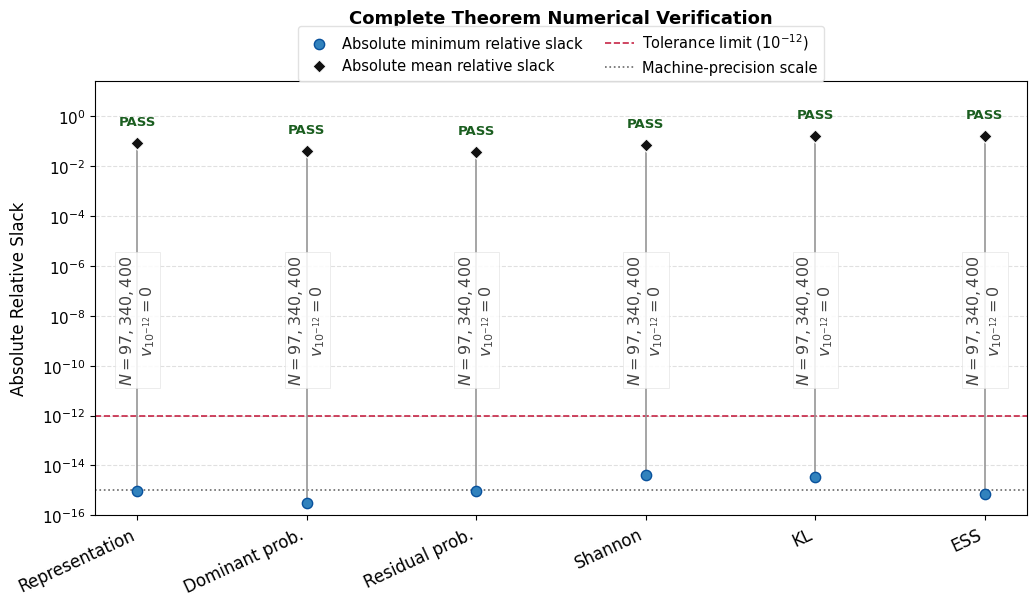

In [9]:
# ==========================================
# Figure 8
# ==========================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.unicode_minus": False,
})

eps = 1e-18

df = pd.read_csv("C:/Users/fredy/Downloads/Results_Extremal_Gibbs_Q1PP_V3_Final/figure_data/v3_fig08_theorem_dashboard.csv")

df["abs_min_slack"] = np.maximum(np.abs(df["minimum_relative_slack"].astype(float)), eps)
df["abs_mean_slack"] = np.maximum(np.abs(df["mean_relative_slack"].astype(float)),eps)

label_map = {
    "Theorem 4": "Representation",
    "Theorem 5": "Dominant prob.",
    "Corollary 5": "Residual prob.",
    "Theorem 6-H": "Shannon",
    "Theorem 6-KL": "KL",
    "Theorem 6-ESS": "ESS",
}

df["theorem"] = df["theorem"].map(label_map).fillna(df["theorem"])

fig, ax = plt.subplots(figsize=(10.5, 6.2))

x = np.arange(len(df))

ax.scatter(
    x,
    df["abs_min_slack"],
    marker="o",
    s=55,
    color="#3182bd",
    edgecolor="#08519c",
    linewidth=1.0,
    zorder=4,
    label="Absolute minimum relative slack",
)

ax.scatter(
    x,
    df["abs_mean_slack"],
    marker="D",
    s=45,
    color="#111111",
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
    label="Absolute mean relative slack",
)

for i in range(len(df)):
    ax.vlines(
        x[i],
        df["abs_min_slack"].iloc[i],
        df["abs_mean_slack"].iloc[i],
        colors="#969696",
        linestyles="-",
        linewidth=1.2,
        zorder=3,
    )

ax.axhline(
    1e-12,
    color="#bd0026",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
    label=r"Tolerance limit ($10^{-12}$)"
)

ax.axhline(
    1e-15,
    color="#4d4d4d",
    linestyle=":",
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
    label="Machine-precision scale"
)

for i, row in df.iterrows():
    ax.text(
        i,
        row["abs_mean_slack"] * 4.0,
        row["status"],
        ha="center",
        va="bottom",
        fontsize=9.5,
        weight="bold",
        color="#1b5e20" if row["status"] == "PASS" else "#b71c1c",
        zorder=6,
    )

    ax.text(
        i,
        0.3,
        rf"$N={int(row['tests']):,}$"
        + "\n"
        + rf"$v_{{10^{{-12}}}}={int(row['violations_tol_1e_minus_12'])}$",
        ha="center",
        va="bottom",
        fontsize=11.5,
        color="#444444",
        rotation=90,
        weight="medium",
        transform=ax.get_xaxis_transform(),
        zorder=6,
        bbox=dict(
            boxstyle="square,pad=0.2",
            facecolor="white",
            edgecolor="#e0e0e0",
            linewidth=0.5,
            alpha=0.85,
        ),
    )

ax.set_yscale("log")

y_max_data = df["abs_mean_slack"].max()
ax.set_ylim(1e-16, y_max_data * 150)

ax.set_xticks(x)
ax.set_xticklabels(df["theorem"], rotation=25, ha="right", fontsize=12)

ax.set_ylabel("Absolute Relative Slack", fontsize=12, labelpad=10)

ax.set_title(
    "Complete Theorem Numerical Verification",
    weight="bold",
    fontsize=13,
    pad=42
)

ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.12, color="black", zorder=1)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=10.5,
    columnspacing=1.5,
    handletextpad=0.6
)

plt.tight_layout()
plt.show()